In [1]:
from qiskit import transpile
import rustworkx
from rustworkx.visualization import graphviz_draw

import sys
import numpy as np
from pathlib import Path
import time
import pickle
import networkx as nx

# Add parent directory to path for network_emulation package
sys.path.insert(0, '..')

# Import from network_emulation package
from network_emulation import (
    # Node utilities
    Node, NODE_NAMES, NUM_NODES, INITIAL_STATES, STATE_LABELS,
    CONNECTION_TUPLES, get_node_name, route_name, get_node_id,
    # Config loading
    load_nodes_config, load_routes_config,
    # Circuit building (including new multi-hop function)
    build_swapping_circuit, build_multihop_swapping_circuit,
    # Experiment execution
    initialize_backend, run_provided_circuit,
    # Visualization & export
    plot_syndrome_matrix, plot_all_states_comparison, plot_state_averages_bar,
    print_matrix_summary, print_full_comparison, save_results_to_json
)

In [2]:
# ============================================================
# EXPERIMENT CONFIGURATION
# ============================================================
# Set USE_REAL_HARDWARE = True to run on actual IBM quantum hardware
# Set USE_REAL_HARDWARE = False to use the FakeFez simulator
# ============================================================

USE_REAL_HARDWARE = False  # Toggle between real hardware and simulator

# Experiment parameters
NUM_SHOTS = 4096           # Number of shots per circuit execution
OPTIMIZATION_LEVEL = 0      # Transpiler optimization (0 = no optimization)

# Configuration file paths
CONFIG_DIR = Path('../configs')
NODES_FILE = CONFIG_DIR / 'config_1_nodes.json'
ROUTES_FILE = CONFIG_DIR / 'config_1_routes.json'
OUTPUT_DIR = Path('../outputs/syndromes')

print("="*60)
print("EXPERIMENT CONFIGURATION")
print("="*60)
print(f"Hardware mode:      {'REAL IBM HARDWARE' if USE_REAL_HARDWARE else 'FakeFez SIMULATOR'}")
print(f"Shots per circuit:  {NUM_SHOTS}")
print(f"Optimization level: {OPTIMIZATION_LEVEL}")
print(f"Initial states:     {[STATE_LABELS[s] for s in INITIAL_STATES]}")
print(f"\nConfig files:")
print(f"  Nodes:  {NODES_FILE} (exists: {NODES_FILE.exists()})")
print(f"  Routes: {ROUTES_FILE} (exists: {ROUTES_FILE.exists()})")


# ============================================================
# LOAD CONFIGURATIONS
# ============================================================

# Load node and route configurations from JSON files
NODES = load_nodes_config(NODES_FILE)
TRANSPORT_ROUTES = load_routes_config(ROUTES_FILE)

print("="*60)
print("LOADED CONFIGURATIONS")
print("="*60)
print(f"\nNodes ({len(NODES)} total):")
for node_id, qubits in NODES.items():
    print(f"  Node {get_node_name(node_id)}: data={qubits['data']}, "
          f"encoding={qubits['encoding']}, ancilla={qubits['ancilla']}")

print(f"\nRoutes ({len(TRANSPORT_ROUTES)} total)")
print(f"Connection pairs: {len(CONNECTION_TUPLES)}")


# ============================================================
# INITIALIZE BACKEND
# ============================================================

# Initialize quantum backend (FakeFez simulator or real IBM Fez)
backend, simulator, coupling_map, IS_REAL_HARDWARE = initialize_backend(
    USE_REAL_HARDWARE,
    secrets_path='../secrets/keys.json',
    simulation_method="matrix_product_state"
)

EXPERIMENT CONFIGURATION
Hardware mode:      FakeFez SIMULATOR
Shots per circuit:  4096
Optimization level: 0
Initial states:     ['|0⟩', '|1⟩', '|+⟩', '|−⟩']

Config files:
  Nodes:  ../configs/config_1_nodes.json (exists: True)
  Routes: ../configs/config_1_routes.json (exists: True)
LOADED CONFIGURATIONS

Nodes (6 total):
  Node A: data=[76], encoding=[61, 81], ancilla=[62, 82]
  Node B: data=[77], encoding=[65, 85], ancilla=[66, 86]
  Node C: data=[78], encoding=[69, 89], ancilla=[70, 90]
  Node D: data=[96], encoding=[83, 103], ancilla=[84, 104]
  Node E: data=[97], encoding=[87, 107], ancilla=[88, 108]
  Node F: data=[98], encoding=[91, 111], ancilla=[92, 112]

Routes (30 total)
Connection pairs: 30
Loaded SIMULATOR backend: fake_fez
  Qubits: 156
  Simulation method: matrix_product_state


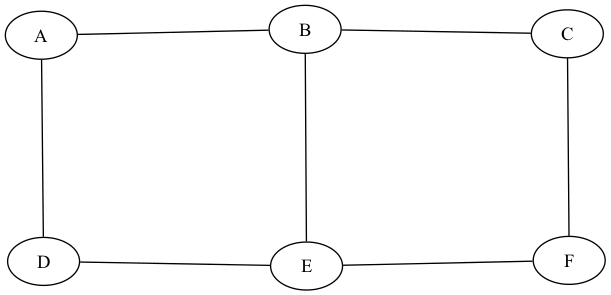

In [3]:
# Build Network Graph to get path edges. 

def node_attr(node):
    return {'label':node[1]}

# def edge_attr():
#     pass



network_graph = rustworkx.PyGraph()
graph_node_indices = {}
for node in NODE_NAMES.items():
    id = network_graph.add_node(node)
    graph_node_indices.update({node[1]: id})

# Add the edges: 
# A -- B -- C
# |    |    |
# D -- E -- F

network_graph.add_edge(graph_node_indices.get('A'), graph_node_indices.get('B'), None)
network_graph.add_edge(graph_node_indices.get('B'), graph_node_indices.get('C'), None)
network_graph.add_edge(graph_node_indices.get('A'), graph_node_indices.get('D'), None)
network_graph.add_edge(graph_node_indices.get('B'), graph_node_indices.get('E'), None)
network_graph.add_edge(graph_node_indices.get('C'), graph_node_indices.get('F'), None)
network_graph.add_edge(graph_node_indices.get('D'), graph_node_indices.get('E'), None)
network_graph.add_edge(graph_node_indices.get('E'), graph_node_indices.get('F'), None)


graphviz_draw(network_graph, node_attr_fn=node_attr, edge_attr_fn=None, method='sfdp')

In [4]:
# Get all the hops and routes:
MAX_HOPS = 2
PATH_DICT = {}
total_paths = 0
for node_id in network_graph.node_indices():
    # print(node_id, network_graph.get_node_data(node_id))
    node = network_graph.get_node_data(node_id)
    paths = {id:rustworkx.all_simple_paths(network_graph, node_id, to=id, cutoff=MAX_HOPS) for id in network_graph.node_indices()}
    paths.pop(node_id)
    # print(paths)
    for dest_id, path_list in paths.items():
        total_paths += len(path_list)
        print(f"From node {node_id} to node {dest_id}: {len(path_list)} paths") 
        print(f"Paths: {path_list}")

    PATH_DICT.update({node_id:paths})

print(f"\nTotal paths found: {total_paths}")

From node 0 to node 1: 1 paths
Paths: [[0, 1]]
From node 0 to node 2: 0 paths
Paths: []
From node 0 to node 3: 1 paths
Paths: [[0, 3]]
From node 0 to node 4: 0 paths
Paths: []
From node 0 to node 5: 0 paths
Paths: []
From node 1 to node 0: 1 paths
Paths: [[1, 0]]
From node 1 to node 2: 1 paths
Paths: [[1, 2]]
From node 1 to node 3: 0 paths
Paths: []
From node 1 to node 4: 1 paths
Paths: [[1, 4]]
From node 1 to node 5: 0 paths
Paths: []
From node 2 to node 0: 0 paths
Paths: []
From node 2 to node 1: 1 paths
Paths: [[2, 1]]
From node 2 to node 3: 0 paths
Paths: []
From node 2 to node 4: 0 paths
Paths: []
From node 2 to node 5: 1 paths
Paths: [[2, 5]]
From node 3 to node 0: 1 paths
Paths: [[3, 0]]
From node 3 to node 1: 0 paths
Paths: []
From node 3 to node 2: 0 paths
Paths: []
From node 3 to node 4: 1 paths
Paths: [[3, 4]]
From node 3 to node 5: 0 paths
Paths: []
From node 4 to node 0: 0 paths
Paths: []
From node 4 to node 1: 1 paths
Paths: [[4, 1]]
From node 4 to node 2: 0 paths
Paths: 

In [5]:
# Run experiement, run data
PATH_SYNDROME_METRICS = []
for src, all_paths in PATH_DICT.items():
    for dst, paths in all_paths.items():
        print(f'\n\nCollecting data for {src} --> {dst}: ')
        for path in paths:
            print('\t', path)
            bit_circuit = build_multihop_swapping_circuit(
                node_path=path,
                initial_state='0',
                nodes = NODES,
                routes=TRANSPORT_ROUTES,
                num_qubits=backend.num_qubits,
                syndrome_type="bit"
            )
            phase_circuit = build_multihop_swapping_circuit(
                node_path=path,
                initial_state='0',
                nodes = NODES,
                routes=TRANSPORT_ROUTES,
                num_qubits=backend.num_qubits,
                syndrome_type="phase"
            )

            bit_syndrome_count, bit_timing_dict = run_provided_circuit(
                circuit=bit_circuit,
                backend=backend,
                simulator=simulator,
                is_real_hardware=IS_REAL_HARDWARE,
                num_shots=NUM_SHOTS,
                optimization_level=OPTIMIZATION_LEVEL,
                return_timing = True
            )

            phase_syndrome_count, phase_timing_dict = run_provided_circuit(
                circuit=phase_circuit,
                backend=backend,
                simulator=simulator,
                is_real_hardware=IS_REAL_HARDWARE,
                num_shots=NUM_SHOTS,
                optimization_level=OPTIMIZATION_LEVEL,
                return_timing = True
            )

            data = {
                'source': src,
                'dest': dst,
                'path': path,
                'bit_syn': bit_syndrome_count,
                'phase_syn': phase_syndrome_count,
                'bit_exec_time': bit_timing_dict['time_taken'],
                'phase_exec_time': phase_timing_dict['time_taken']  
            }
            print(data)
            print('\n')
            PATH_SYNDROME_METRICS.append(data)





	 [0, 1]
{'source': 0, 'dest': 1, 'path': [0, 1], 'bit_syn': {'00': 2888, '01': 419, '10': 428, '11': 361}, 'phase_syn': {'00': 2725, '01': 480, '10': 461, '11': 430}, 'bit_exec_time': 6.393840074539185, 'phase_exec_time': 10.914531707763672}






	 [0, 3]
{'source': 0, 'dest': 3, 'path': [0, 3], 'bit_syn': {'00': 3367, '01': 213, '10': 315, '11': 201}, 'phase_syn': {'00': 3249, '01': 256, '10': 342, '11': 249}, 'bit_exec_time': 3.72407603263855, 'phase_exec_time': 4.672215938568115}








	 [1, 0]
{'source': 1, 'dest': 0, 'path': [1, 0], 'bit_syn': {'00': 2860, '01': 450, '10': 385, '11': 401}, 'phase_syn': {'00': 2729, '01': 437, '10': 495, '11': 435}, 'bit_exec_time': 5.554127216339111, 'phase_exec_time': 7.6096577644348145}




	 [1, 2]
{'source': 1, 'dest': 2, 'path': [1, 2], 'bit_syn': {'00': 1016, '01': 1052, '10': 985, '11': 1043}, 'phase_syn': {'00': 1029, '01': 1035, '10': 1048, '11': 984}, 'bit_exec_time': 3.8281259536743164, 'phase_exec_time': 6.507349967956543}








In [6]:
import json
from datetime import datetime
date = datetime.today().strftime("%d-%m-%Y_%H:%M:%S")
print(date)


24-01-2026_18:24:09


In [7]:
with open(f'{CONFIG_DIR}/config_1_data_{date}.json', 'w') as f:
    json.dump(PATH_SYNDROME_METRICS, f, indent=2)

f.close()

with open(f'{CONFIG_DIR}/config_1_paths_{MAX_HOPS}_maxhops.json', 'w') as f:
    json.dump(PATH_DICT, f, indent=2)

In [8]:
class TimeAwareMeasurement:
    def __init__(self, path_edges, histogram, duration, latency_stats=None, code_type='513'):
        """
        :param path_edges: List of tuples representing the path, e.g., [(0,1), (1,2)]
        :param histogram: A 16-dimensional numpy array of syndrome counts.
        :param duration: The duration or average latency of this measurement (seconds).
        :param latency_stats: A dictionary with 'max', 'std', 'count'.
        :param code_type: String indicating the code type, e.g., '313_X', '313_Z', '513'.
        """
        self.path_edges = path_edges
        self.histogram = histogram
        self.duration = duration
        self.latency_stats = latency_stats
        self.code_type = code_type  # Default, will be updated per sample

# ==========================================
# 2. Main Export Function
# ==========================================
def export_real_data(
    output_dir,
    topology_graph,
    raw_measurement_data,
    physical_params
):
    """
    Saves real data into .pkl files compatible with the training pipeline.

    :param output_dir: String, folder path to save files.
    :param topology_graph: networkx.Graph object representing the physical network.
    :param raw_measurement_data: List of dictionaries containing your real data.
    :param physical_params: Dictionary of physical parameters (T1, T2, etc.).
    """
    output_path = Path(output_dir)
    output_path.mkdir(parents=True, exist_ok=True)

    print(f"--- Exporting Data to {output_dir} ---")

    # -------------------------------------------------
    # Step A: Save Graph Topology (graph.pkl)
    # -------------------------------------------------
    # Ensure the graph uses integer Node IDs consistent with path_edges
    with open(output_path / "graph.pkl", "wb") as f:
        pickle.dump(topology_graph, f)
    print(f"[OK] Saved graph.pkl with {len(topology_graph.nodes)} nodes.")

    # -------------------------------------------------
    # Step B: Process and Save Measurements (measurements.pkl)
    # -------------------------------------------------
    formatted_measurements = []

    for sample in raw_measurement_data:
        # 1. Extract raw data from your source
        # sample['path']: e.g., [0, 1, 2]
        # sample['counts']: e.g., [100, 5, 2, 0] (for 313 code)
        # sample['code']: '313_X' or '313_Z' or '513'
       
        # --- CRITICAL 1: Format Path Edges ---
        # Convert list of nodes [0, 1, 2] -> list of sorted edges [(0,1), (1,2)]
        node_path = sample['path']
        edges = []
        for i in range(len(node_path) - 1):
            u, v = node_path[i], node_path[i+1]
            # Edges MUST be sorted: (min, max)
            edges.append(tuple(sorted((u, v))))

        # --- CRITICAL 2: Format Histogram (Padding) ---
        # The training model strictly requires an input dimension of 16.
        # Even if you use 313 codes (4 syndromes), you must pad with zeros.
       
        raw_counts = np.array(sample['counts'], dtype=np.float32)
        padded_histogram = np.zeros(16, dtype=np.float32)

        # Copy real data into the beginning of the array
        # If 313 code (len 4), indices 0-3 are filled, 4-15 remain 0.
        # If 513 code (len 16), indices 0-15 are filled.
        current_len = len(raw_counts)
        padded_histogram[:current_len] = raw_counts

        # --- 3. Create Object ---
        meas_obj = TimeAwareMeasurement(
            path_edges=edges,
            histogram=padded_histogram,
            duration=sample['duration'],  # in seconds
            latency_stats=sample.get('stats', {'max': 0, 'std': 0, 'count': 0})
        )
        meas_obj.code_type = sample['code'] # Explicitly set code type
       
        formatted_measurements.append(meas_obj)

    with open(output_path / "measurements.pkl", "wb") as f:
        pickle.dump(formatted_measurements, f)
    print(f"[OK] Saved measurements.pkl with {len(formatted_measurements)} samples.")

    # -------------------------------------------------
    # Step C: Save Metadata (metadata.pkl)
    # -------------------------------------------------
    # This helps the script normalize time values.
    # Calculate min/max time from your actual data if not provided.
    durations = [m.duration for m in formatted_measurements]
   
    metadata = {
        't1': physical_params.get('t1', 1.0),
        't2': physical_params.get('t2', 1.0),
        'alpha': physical_params.get('alpha', 0.6),
        'min_time': min(durations) if durations else 0.0,
        'max_time': max(durations) if durations else 1.0,
        'test_pairs': [] # Optional: list of (src, dst) tuples reserved for testing
    }
   
    with open(output_path / "metadata.pkl", "wb") as f:
        pickle.dump(metadata, f)
    print("[OK] Saved metadata.pkl")



In [9]:

formatted_measurement_data = []
for measurement in PATH_SYNDROME_METRICS:
    print(measurement)
    path = measurement['path']
    path_tuples = list(zip(path[:-1], path[1:]))
    print(path_tuples)
    bit_syndrome = list(measurement['bit_syn'].values())
    phase_syndrome = list(measurement['phase_syn'].values())
    print(bit_syndrome, phase_syndrome)
    bit_syn_time = measurement['bit_exec_time'] / sum(bit_syndrome)
    phase_syn_time = measurement['phase_exec_time'] / sum(phase_syndrome)
    print(bit_syn_time, phase_syn_time)
    bit_syndrome_measurement = TimeAwareMeasurement(
        path_edges=path_tuples,
        histogram=np.array(bit_syndrome + [0]*12, dtype=np.float32),
        duration=0.0,
        latency_stats={},
        code_type='313_X'
    )
    phase_syndrome_measurement = TimeAwareMeasurement(
        path_edges=path_tuples,
        histogram=np.array(phase_syndrome + [0]*12, dtype=np.float32),
        duration=0.0,
        latency_stats={},
        code_type='313_Z'
    )

    formatted_measurement_data.append(bit_syndrome_measurement)
    formatted_measurement_data.append(phase_syndrome_measurement)



{'source': 0, 'dest': 1, 'path': [0, 1], 'bit_syn': {'00': 2888, '01': 419, '10': 428, '11': 361}, 'phase_syn': {'00': 2725, '01': 480, '10': 461, '11': 430}, 'bit_exec_time': 6.393840074539185, 'phase_exec_time': 10.914531707763672}
[(0, 1)]
[2888, 419, 428, 361] [2725, 480, 461, 430]
0.001560996111948043 0.00266468059271574
{'source': 0, 'dest': 3, 'path': [0, 3], 'bit_syn': {'00': 3367, '01': 213, '10': 315, '11': 201}, 'phase_syn': {'00': 3249, '01': 256, '10': 342, '11': 249}, 'bit_exec_time': 3.72407603263855, 'phase_exec_time': 4.672215938568115}
[(0, 3)]
[3367, 213, 315, 201] [3249, 256, 342, 249]
0.000909198250155896 0.0011406777193769813
{'source': 1, 'dest': 0, 'path': [1, 0], 'bit_syn': {'00': 2860, '01': 450, '10': 385, '11': 401}, 'phase_syn': {'00': 2729, '01': 437, '10': 495, '11': 435}, 'bit_exec_time': 5.554127216339111, 'phase_exec_time': 7.6096577644348145}
[(1, 0)]
[2860, 450, 385, 401] [2729, 437, 495, 435]
0.0013559880899265409 0.0018578266026452184
{'source': 1,

In [10]:

# Save to pickle file
print('Saving to pickle files...')
output_path = Path(f"../pickle_files/data_{date}")
output_path.mkdir(parents=True, exist_ok=True)
measurements_file = output_path / "measurements.pkl"
with open(measurements_file, "wb") as f:
    pickle.dump(formatted_measurement_data, f)
    print(f"[OK] Saved measurements.pkl with {len(formatted_measurement_data)} samples.")


Saving to pickle files...
[OK] Saved measurements.pkl with 28 samples.


In [11]:
graph = nx.Graph()
for edge in network_graph.edge_list():
    print(edge)
    u,v = edge
    graph.add_edge(u, v)
graph_file = output_path / "graph.pkl"

with open(graph_file, "wb") as f:
    pickle.dump(graph, f)
    print(f"[OK] Saved graph.pkl with {len(graph.nodes)} nodes.")

(0, 1)
(1, 2)
(0, 3)
(1, 4)
(2, 5)
(3, 4)
(4, 5)
[OK] Saved graph.pkl with 6 nodes.
